# Exploratory Data Analysis

- Dataset inspection
- Message length distribution
- Dialogue length distribution
- Same-user turn analysis
- Vocabulary exploration

Setup
---

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', None)

df = pd.read_csv('./data/Ubuntu-dialogue-corpus/dialogueText.csv')

print("Shape:", df.shape)
df.head()

Shape: (1038324, 6)


,folder,dialogueID,date,from,to,text
0,3,126125.tsv,2008-04-23T14:55:00.000Z,bad_image,NaN,"Hello folks, please help me a bit with the following sentence: 'Order here your personal photos or videos.' - I think the only allowed version is 'Order your personal videos or photos here.', but I'm not sure, are you?"
1,3,126125.tsv,2008-04-23T14:56:00.000Z,bad_image,NaN,Did I choose a bad channel? I ask because you seem to be dumb like windows user
2,3,126125.tsv,2008-04-23T14:57:00.000Z,lordleemo,bad_image,the second sentence is better english and we are not dumb
3,3,64545.tsv,2009-08-01T06:22:00.000Z,mechtech,NaN,Sock Puppe?t
4,3,64545.tsv,2009-08-01T06:22:00.000Z,mechtech,NaN,WTF?


# 1. Message length distribution
- This helps justify the decision for MAX_LENGTH

count    1.038235e+06
mean     1.059930e+01
std      1.031706e+01
min      0.000000e+00
25%      4.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.070000e+02
Name: msg_length, dtype: float64


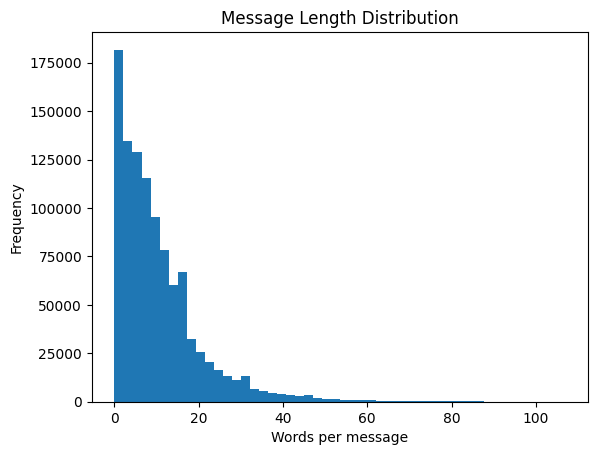

In [3]:
df = df.dropna(subset=['text'])

df['msg_length'] = df['text'].astype(str).apply(lambda x: len(x.split()))

print(df['msg_length'].describe())

plt.hist(df['msg_length'], bins=50)
plt.title("Message Length Distribution")
plt.xlabel("Words per message")
plt.ylabel("Frequency")
plt.show()

# 2. Dialogue length distribution
- This supports our context window design

count    346108.000000
mean          2.999743
std           0.018384
min           1.000000
25%           3.000000
50%           3.000000
75%           3.000000
max           3.000000
dtype: float64


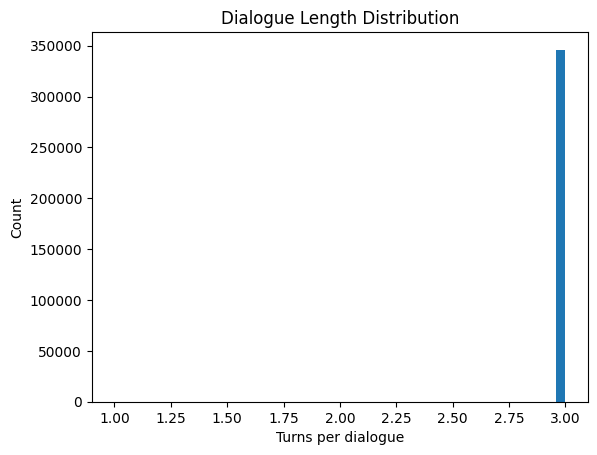

In [4]:
dialogue_lengths = df.groupby(['folder','dialogueID']).size()

print(dialogue_lengths.describe())

plt.hist(dialogue_lengths, bins=50)
plt.title("Dialogue Length Distribution")
plt.xlabel("Turns per dialogue")
plt.ylabel("Count")
plt.show()

# 3. Pair Quality Diagnostics
- How often does the same user appears in consecutive turns?
- This can indicate noisy pairing due to the presence of multi-user conversations.

In [5]:
same_user_pairs = 0
total_pairs = 0

grouped = df.groupby(['folder', 'dialogueID'])

for _, dialogue in grouped:
    dialogue = dialogue.reset_index(drop=True)

    for i in range(1, len(dialogue)):
        total_pairs += 1
        
        sender_prev = dialogue.loc[i-1, 'from']
        sender_curr = dialogue.loc[i, 'from']
        
        if sender_prev == sender_curr:
            same_user_pairs += 1

percentage = (same_user_pairs / total_pairs) * 100

print("Pair Quality Diagnostic")
print("----------------------")
print(f"Total consecutive turns: {total_pairs}")
print(f"Same-user turns: {same_user_pairs}")
print(f"Percentage same-user turns: {percentage:.2f}%")

Pair Quality Diagnostic
----------------------
Total consecutive turns: 692127
Same-user turns: 261225
Percentage same-user turns: 37.74%


# 4. Vocabulary Coverage Analysis
- How much of the text is still representable if we drop rare words?
- This helps justify the decision for MIN_TOKEN_FREQ

In [6]:
from collections import Counter

print("Vocabulary Coverage Analysis")
print("----------------------------")

counter = Counter()

for text in df['text'].dropna():
    tokens = text.lower().split()
    counter.update(tokens)

total_tokens = sum(counter.values())

for min_freq in [1,2,3,5,10]:
    kept_tokens = sum(c for w,c in counter.items() if c >= min_freq)
    vocab_size = sum(1 for w,c in counter.items() if c >= min_freq)

    print(f"min_freq={min_freq}")
    print(f"  vocab_size={vocab_size}")
    print(f"  coverage={(kept_tokens/total_tokens):.2%}")

Vocabulary Coverage Analysis
----------------------------
min_freq=1
  vocab_size=369203
  coverage=100.00%
min_freq=2
  vocab_size=125137
  coverage=97.78%
min_freq=3
  vocab_size=76708
  coverage=96.90%
min_freq=5
  vocab_size=48031
  coverage=96.02%
min_freq=10
  vocab_size=28233
  coverage=94.86%


# 5. GloVe Coverage Analysis
- How much of our dataset vocabulary appears in pretrained embeddings?
- This helps assess their suitability.

GloVe Coverage Analysis
----------------------
Dataset vocab size: 369203
GloVe vocab size: 400000
Tokens covered by GloVe: 38051
GloVe coverage: 10.31%


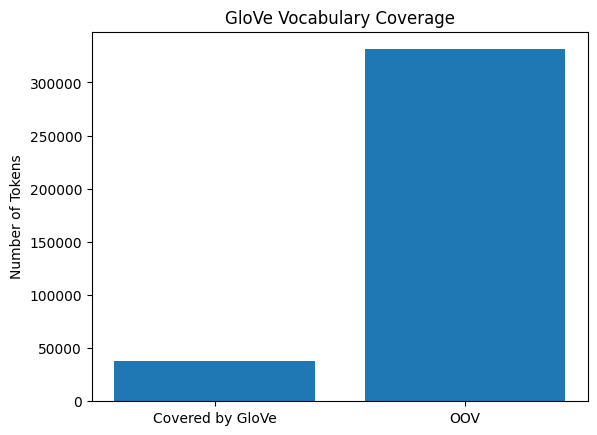

Top words kept  In GloVe  
100             95.00%
500             90.00%
1000            84.90%
2000            76.60%
5000            63.26%


In [17]:
import numpy as np

print("GloVe Coverage Analysis")
print("----------------------")

# Loading GloVe vocabulary 
glove_path = "./data/glove.6B.200d.txt"

glove_vocab = set()

with open(glove_path, "r", encoding="utf8") as f:
    for line in f:
        token = line.split()[0]
        glove_vocab.add(token)

dataset_vocab = set(counter.keys())

in_glove = dataset_vocab.intersection(glove_vocab)

coverage = len(in_glove) / len(dataset_vocab)

print(f"Dataset vocab size: {len(dataset_vocab)}")
print(f"GloVe vocab size: {len(glove_vocab)}")
print(f"Tokens covered by GloVe: {len(in_glove)}")
print(f"GloVe coverage: {coverage:.2%}")

covered = 0
not_covered = 0

for token in dataset_vocab:
    if token in glove_vocab:
        covered += 1
    else:
        not_covered += 1

plt.bar(["Covered by GloVe", "OOV"], [covered, not_covered])
plt.title("GloVe Vocabulary Coverage")
plt.ylabel("Number of Tokens")
plt.show()

# 6. Percentage of Rare Words
- This serves to diagnose vocabulary sparsity

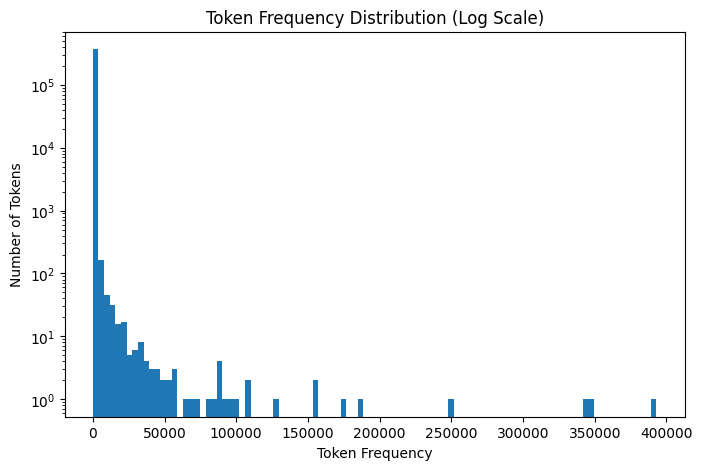

In [8]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

counter = Counter()

for text in df['text'].dropna():
    tokens = text.lower().split()
    counter.update(tokens)

freqs = list(counter.values())

plt.figure(figsize=(8,5))
plt.hist(freqs, bins=100, log=True)
plt.title("Token Frequency Distribution (Log Scale)")
plt.xlabel("Token Frequency")
plt.ylabel("Number of Tokens")
plt.show()

# 7. Out of Vocabulary Tokens - Examples

In [9]:
oov_tokens = dataset_vocab - glove_vocab
print("Sample OOV tokens:")
print(list(oov_tokens)[:30])

Sample OOV tokens:
['names..if', 'http://www.winehq.com/site/download-deb', 'natbib?', 'npviewer', 'next:', 'ohh...was', 'mathmatics,', 'source..or', 'develop?', 'fireburner', 'post-feisty.', 'mirrorselect', './whateverthebinfileiscalled.bin', 'öä.txt', 'kuro5hin.org', 'site2site', 'upgrading/installing', '(ctrl-alt-backspace)', 'controlls', '-every-', 'somsone', 'sheat', 'luke..', 'here/.', 'http://ubuntuguide.org/wiki/ubuntu:feisty#how_to_install_flash_player_.28macromedia_flash.29_plug-in_for_mozilla_firefox', 'wreless', 'usb....etc', 'network!?', 'disc/iso', "enable_msi=1'"]


# 8. Coverage of Frequent Words
- If we keep only the top N words, how much of the corpus do they represent?
- It helps to select a reasonable vocabulary cutoff
- Assuming that a small number of words dominate, this can justify the decision for truncating vocabulary to 20k tokens

In [16]:
total_tokens = sum(counter.values())

top_tokens = [word for word, _ in counter.most_common(5000)]

covered = sum(1 for w in top_tokens if w in glove_vocab)

print(f"Coverage of top 5000 tokens: {covered/len(top_tokens):.2%}")
print(f"---------------------------")

sizes = [100, 500, 1000, 2000, 5000]

print(f"{'Top words kept':<15} {'Corpus coverage':<15}")

for k in sizes:
    top_k = counter.most_common(k)
    covered_tokens = sum(freq for _, freq in top_k)
    coverage = covered_tokens / total_tokens
    print(f"{k:<15} {coverage:.2%}")

Coverage of top 5000 tokens: 63.26%
---------------------------
Top words kept  Corpus coverage
100             49.75%
500             69.29%
1000            76.38%
2000            82.46%
5000            88.45%


# 9. Vocabulary Coverage After Filtering < UNK >
- This should quantify how much information is lost when rare words become < UNK >

In [13]:
MIN_TOKEN_FREQ = 5

total_tokens = sum(counter.values())
kept_tokens = sum(count for word, count in counter.items() if count >= MIN_TOKEN_FREQ)

print("Token coverage after filtering:")
print(f"Coverage: {kept_tokens / total_tokens:.2%}")

Token coverage after filtering:
Coverage: 96.02%


# 10. Visualising Decoder Attention (draft) 
- Attention scores are normalised using a softmax function to produce attention weights. We're visualising this as a heatmap to highlight which input tokens the model attends to when generating each output token:
- Columns = the x-axis to represent input tokens processed by the encoder
- Rows = y-axis to represent tokens generated by the decoder at each timestep
- Colour intensity = how much attention the model assigned to an input token when generating an output token.

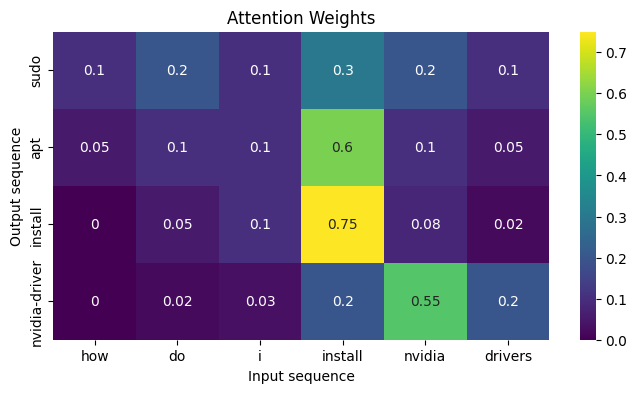

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Example input and output tokens
input_tokens = ["how", "do", "i", "install", "nvidia", "drivers"]
output_tokens = ["sudo", "apt", "install", "nvidia-driver"]

# Example attention matrix (rows = output, columns = input)
attention_matrix = np.array([
    [0.10, 0.20, 0.10, 0.30, 0.20, 0.10],  # attention when generating "sudo"
    [0.05, 0.10, 0.10, 0.60, 0.10, 0.05],  # attention when generating "apt"
    [0.00, 0.05, 0.10, 0.75, 0.08, 0.02],  # attention when generating "install"
    [0.00, 0.02, 0.03, 0.20, 0.55, 0.20]   # attention when generating "nvidia-driver"
])

plt.figure(figsize=(8,4))

sns.heatmap(
    attention_matrix,
    xticklabels=input_tokens,
    yticklabels=output_tokens,
    cmap="viridis",
    annot=True)

plt.xlabel("Input sequence")
plt.ylabel("Output sequence")
plt.title("Attention Weights")
plt.show()